# Data-style presets: name a look, pass a field

cleopatra ships a small library of ready-to-use **data-style presets** in
[`cleopatra.styling.colors.DATA_STYLES`](../../reference/colors-glyph.md). Each preset is a complete
look -- a colormap, a sensible range policy, an opacity policy, and a labelled legend -- bundled
under a name. You pick one by name and hand it a field:

```python
apply_data_style(ax, {"temperature": my_array}, style="temperature")
```

This notebook covers the climate/GIS presets (`temperature`, `elevation`, `vegetation`,
`wind_speed`, `anomaly`, `precipitation`), the official CAMS aerosol colormaps
(`CAMS_AOD_COLORMAPS`), and the three capabilities that let one preset work on real data:
**auto-ranging**, **diverging** maps centred on a value, and the **opacity policy** (a plain
opaque field vs a transparent-where-low overlay).

The scientific-colormap packages (cmocean, CMasher) ship *colormaps*, not presets, so
these presets are authored in cleopatra from matplotlib's built-in colormaps -- no extra
dependency. See the companion [haze preset notebook](../haze_preset/haze_preset_examples.ipynb)
for the stylised, multi-layer aerosol look.

## Setup

We import `apply_data_style` (the one
call that applies a preset), the `DATA_STYLES` registry (to list what is available), and
`CAMS_AOD_COLORMAPS` (the official aerosol colormaps).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cleopatra.styling.colors import CAMS_AOD_COLORMAPS, DATA_STYLES, apply_data_style

sorted(DATA_STYLES)  # the presets available by name

['aerosol_optical_depth_550nm',
 'air_temperature',
 'anomaly',
 'bathymetry',
 'cams_aod',
 'carbon_monoxide',
 'ch4_column_mean_molar_fraction',
 'chlorophyll',
 'cloudy_brightness_temperature',
 'co2_column_mean_molar_fraction',
 'convective_available_potential_energy',
 'convective_available_potential_energy_index',
 'convective_available_potential_energy_shear',
 'convective_available_potential_energy_shear_index',
 'convective_inhibition',
 'convective_precipitation',
 'convective_rainfall_rate',
 'current_speed',
 'dewpoint_temperature_2m',
 'dissolved_oxygen',
 'divergence',
 'dust_aerosol_optical_depth_550nm',
 'elevation',
 'elevation_bukavu',
 'elevation_fes',
 'elevation_oleron',
 'flood_status',
 'flow_accumulation',
 'flow_direction_d8',
 'haze',
 'high_cloud_cover',
 'hot_cold',
 'hurricane_probability',
 'k_index',
 'large_scale_precipitation',
 'large_scale_rainfall_rate',
 'low_cloud_cover',
 'max_significant_wave_height',
 'max_significant_wave_height_index',
 'max_t

### Synthetic demo fields

cleopatra takes NumPy arrays in and returns matplotlib artists out -- it never reads files. So
we build small, physically-plausible synthetic fields on a European lon/lat grid: a temperature
gradient (cooler to the north), two mountain ranges, a vegetation patch, a wind plume, a
positive/negative anomaly dipole, and a localised rain cell. Each stands in for the kind of
raster or NetCDF slice you would normally load with `pyramids`.

In [2]:
lon = np.linspace(-20, 40, 160)
lat = np.linspace(30, 70, 100)
LON, LAT = np.meshgrid(lon, lat)


def blob(cx, cy, sx, sy):
    """A smooth Gaussian bump centred at (cx, cy) in degrees."""
    return np.exp(-(((LON - cx) / sx) ** 2 + ((LAT - cy) / sy) ** 2))

In [3]:
fields = {
    'temperature': 25 - 0.6 * (LAT - 30) + 4 * blob(10, 45, 15, 8),  # deg C
    'elevation': 2600 * blob(8, 46, 6, 4) + 1800 * blob(25, 52, 5, 6),  # m
    'vegetation': np.clip(0.15 + 0.8 * blob(5, 50, 20, 14), 0, 1),  # NDVI
    'wind_speed': 22 * blob(15, 55, 10, 7),  # m/s
    'anomaly': 5 * blob(5, 50, 8, 6) - 4 * blob(28, 45, 8, 7),  # +/-
    'precipitation': 60 * blob(18, 58, 7, 5),  # mm
}
{k: (round(float(v.min()), 1), round(float(v.max()), 1)) for k, v in fields.items()}

{'temperature': (1.0, 25.1),
 'elevation': (0.0, 2595.4),
 'vegetation': (0.2, 0.9),
 'wind_speed': (0.0, 22.0),
 'anomaly': (-4.0, 5.0),
 'precipitation': (0.0, 59.9)}

## Quickstart -- pick a preset by name

One call applies the whole look. `apply_data_style` takes the axes, a `{layer: array}` mapping,
and the preset `style`. It draws the field with the preset's colormap and range, and adds the
labelled swatch legend. It returns the matplotlib image artist(s), so you keep full control of
the axes afterwards.

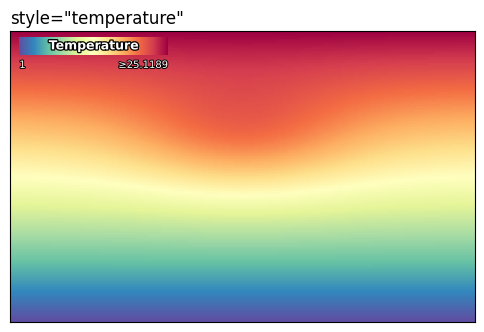

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
apply_data_style(ax, {'temperature': fields['temperature']}, style='temperature')
ax.set_title('style="temperature"', loc='left')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

The `temperature` preset used matplotlib's `RdYlBu_r` colormap (blue = cold, red = hot), ranged
itself to this field's own min/max, drew the whole field opaque, and captioned the legend
"Temperature" -- none of which you had to specify.

## The preset library at a glance

Every climate/GIS preset applied to its matching field. Notice the two *kinds* of look: the
first five fill the whole panel (opaque fields), while `precipitation` is an **overlay** -- the
grey axes background shows through wherever it is dry.

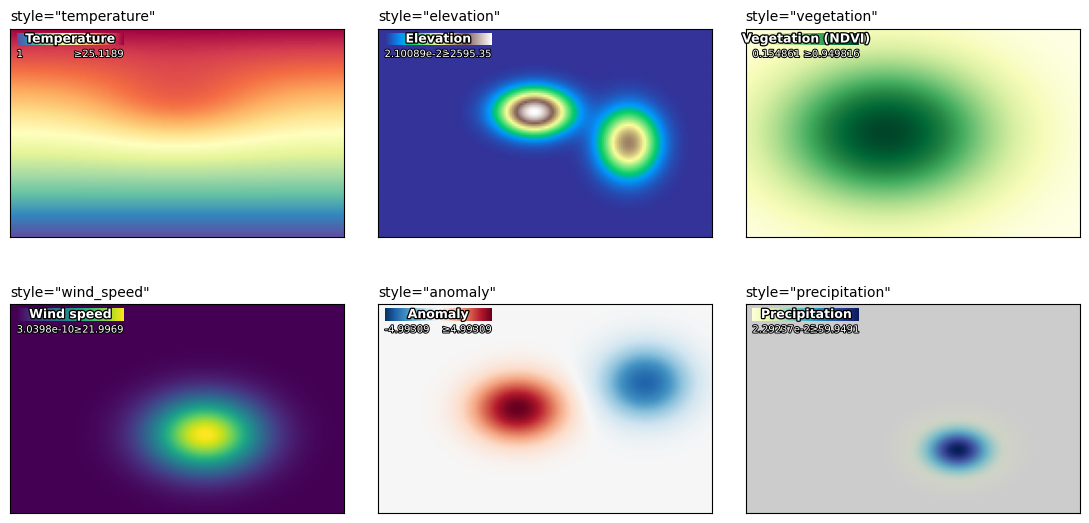

In [5]:
gallery = [
    'temperature',
    'elevation',
    'vegetation',
    'wind_speed',
    'anomaly',
    'precipitation',
]
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, style in zip(axes.ravel(), gallery):
    ax.set_facecolor('#cccccc')
    apply_data_style(ax, {style: fields[style]}, style=style)
    ax.set_title(f'style="{style}"', loc='left', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

| Preset | Colormap | Range | Opacity |
| --- | --- | --- | --- |
| `temperature` | `RdYlBu_r` | auto | opaque |
| `elevation` | `terrain` | auto | opaque |
| `vegetation` | `YlGn` | auto | opaque |
| `wind_speed` | `viridis` | auto | opaque |
| `anomaly` | `RdBu_r` | diverging around 0 | opaque |
| `precipitation` | `YlGnBu` | auto | value-linked overlay |

The layer key must match the preset's layer name (shown above it equals the preset name); pass a
different field under that key to style any raster with that look.

## The official CAMS aerosol colormaps

`CAMS_AOD_COLORMAPS` holds the four real CAMS aerosol-optical-depth (AOD at 550 nm) colour
scales, transcribed from the open-source Magics engine. They are ordinary
`matplotlib.colors.Colormap` objects -- usable anywhere a `cmap` is accepted -- and the
`cams_aod` preset wires the canonical `blue_yellow_red` one into `DATA_STYLES`.

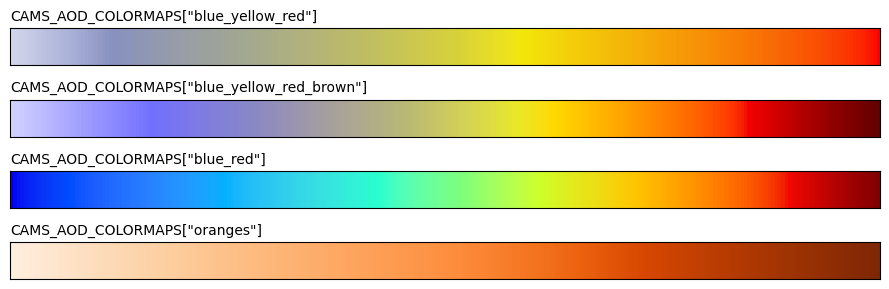

In [6]:
grad = np.linspace(0, 1, 256).reshape(1, -1)
fig, axes = plt.subplots(len(CAMS_AOD_COLORMAPS), 1, figsize=(9, 3))
for ax, (name, cmap) in zip(axes, CAMS_AOD_COLORMAPS.items()):
    ax.imshow(grad, aspect='auto', cmap=cmap)
    ax.set_title(f'CAMS_AOD_COLORMAPS["{name}"]', loc='left', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Because these are the authentic CAMS colours (not an approximation), a plot made with the
`cams_aod` preset matches the look of an official CAMS aerosol chart.

## Capability 1 -- auto-ranging

Real fields do not live on a fixed 0-1 scale. A preset that omits `vmin`/`vmax` **auto-ranges**
to each field's own finite min/max, so the *same* preset looks right whether temperature is in
degrees Celsius or kelvin -- only the legend numbers change.

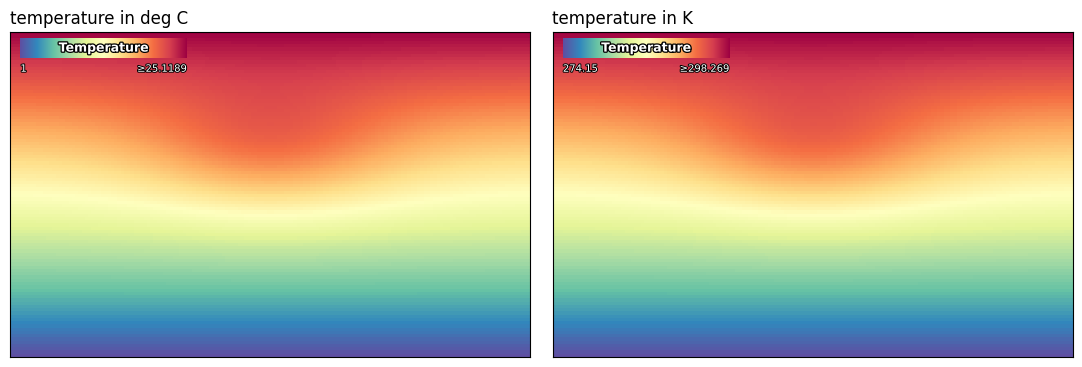

In [7]:
celsius = fields['temperature']
kelvin = celsius + 273.15
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (unit, data) in zip(axes, {'deg C': celsius, 'K': kelvin}.items()):
    apply_data_style(ax, {'temperature': data}, style='temperature')
    ax.set_title(f'temperature in {unit}', loc='left')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Identical colours, different legend extents -- the preset adapted to each field's range. To pin
a fixed scale instead (e.g. to compare two dates on one colour range), a preset can still carry
explicit `vmin`/`vmax`.

## Capability 2 -- diverging maps centred on a value

Anomaly fields read best as a **diverging** map with zero at the neutral midpoint colour. The
`anomaly` preset sets `center=0`, so it builds a range symmetric about zero -- the `RdBu_r`
midpoint (white) lands exactly on 0 even when the data is lopsided (here it runs about -4 to +5).

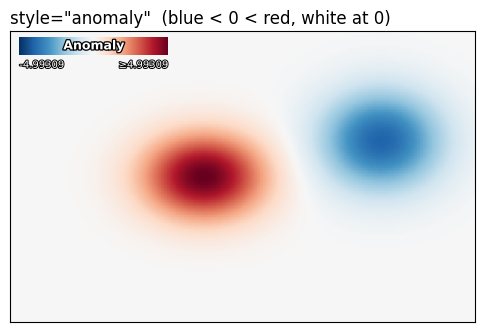

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
apply_data_style(ax, {'anomaly': fields['anomaly']}, style='anomaly')
ax.set_title('style="anomaly"  (blue < 0 < red, white at 0)', loc='left')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

The positive lobe is red, the negative lobe blue, and the neutral background is white -- so the
colour tells you the *sign* at a glance, which an auto-ranged sequential map could not.

## Capability 3 -- opacity policy: opaque field vs overlay

The presets differ deliberately in how opacity relates to value. An **opaque** preset
(`temperature`) fills every cell; an **overlay** preset (`precipitation`) fades to transparent
where the value is low, so a basemap shows through. Drawn over the same grey backdrop, the
contrast is clear.

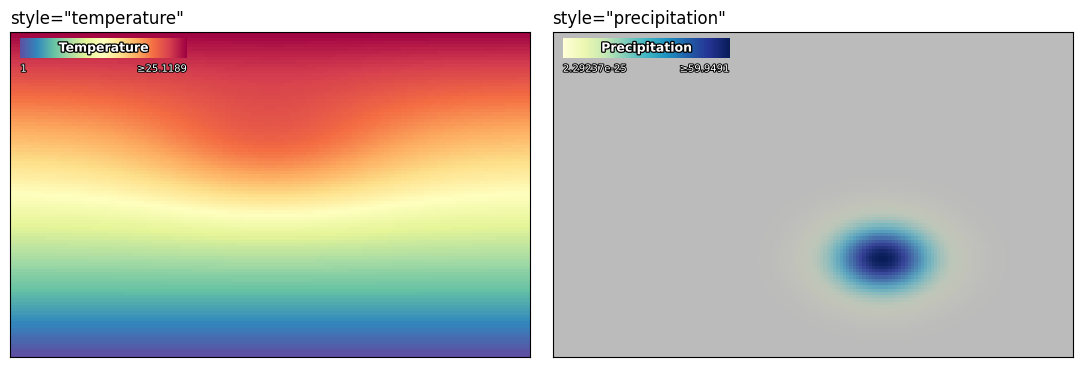

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, style in zip(axes, ['temperature', 'precipitation']):
    ax.set_facecolor('#bbbbbb')
    apply_data_style(ax, {style: fields[style]}, style=style)
    ax.set_title(f'style="{style}"', loc='left')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

`temperature` hides the backdrop completely; `precipitation` reveals it everywhere the rain
cell fades out -- exactly what you want when compositing a signal field over a map. (A third
policy, a decoupled *glowing rim*, powers the multi-layer `haze` preset in its own notebook.)

## The full weather parameter library

Beyond the handful of hand-authored presets, `DATA_STYLES` also carries a **merged weather
parameter-preset library** -- dozens of official operational-forecast and climate looks, loaded
from vendored colour data (derived from the open-source
Magics and
reference styles, both Apache-2.0). Each is keyed
by a descriptive parameter name and labelled with the parameter's real name.

In [10]:
hand_authored = {
    'haze',
    'cams_aod',
    'temperature',
    'elevation',
    'vegetation',
    'wind_speed',
    'anomaly',
    'precipitation',
}
weather = sorted(set(DATA_STYLES) - hand_authored)
print(f'{len(weather)} weather presets loaded, e.g.:')
for key in [
    'temperature_2m',
    'total_precipitation',
    'aerosol_optical_depth_550nm',
    'carbon_monoxide',
    'ozone',
    'high_cloud_cover',
]:
    print(f'  {key:28s} -> {DATA_STYLES[key][key]["label"]}')

103 weather presets loaded, e.g.:
  temperature_2m               -> 2 m temperature [celsius]
  total_precipitation          -> Total precipitation
  aerosol_optical_depth_550nm  -> Total aerosol optical depth at 550 nm
  carbon_monoxide              -> Carbon monoxide
  ozone                        -> GEMS Ozone
  high_cloud_cover             -> High cloud cover


Because these come from open-source reference colour data (which does not always publish the exact
contour levels), each preset either auto-ranges to your field or renders over a fixed scale -- and
the opacity policy is inferred from the source palette: opaque for a plain field, or a
transparent-where-low overlay where the source palette carries a built-in alpha ramp (as it does
for cloud cover). Below, four parameters over a grey backdrop: the first three fill the panel,
while `high_cloud_cover` lets the backdrop show through.

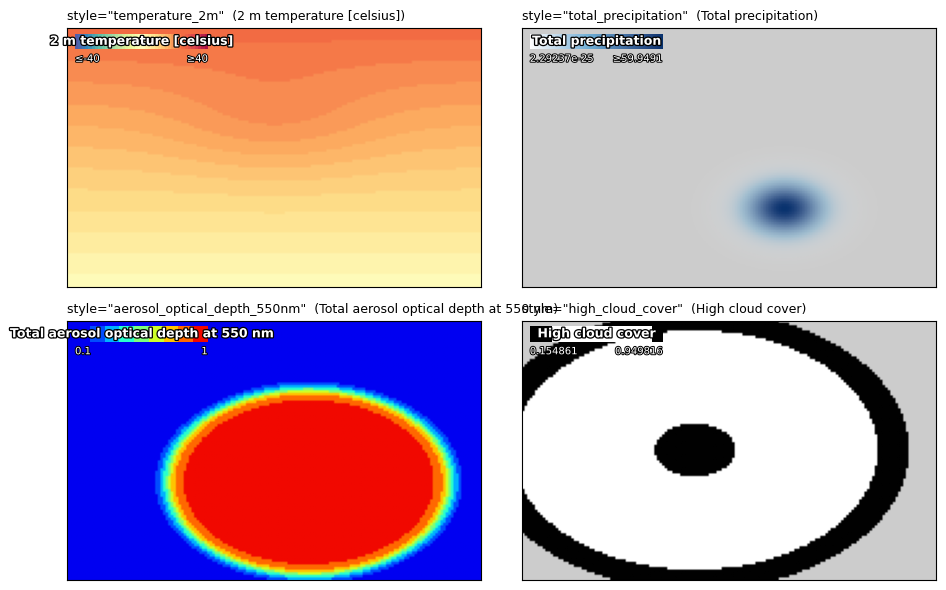

In [11]:
weather_demo = {
    'temperature_2m': 'temperature',
    'total_precipitation': 'precipitation',
    'aerosol_optical_depth_550nm': 'wind_speed',
    'high_cloud_cover': 'vegetation',
}
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, (style, src) in zip(axes.ravel(), weather_demo.items()):
    ax.set_facecolor('#cccccc')
    apply_data_style(ax, {style: fields[src]}, style=style)
    ax.set_title(
        f'style="{style}"  ({DATA_STYLES[style][style]["label"]})',
        loc='left',
        fontsize=9,
    )
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

The demo fields are reused only to fill the panels -- what matters is that any raster or NetCDF
slice you pass under the preset's key gets the authentic reference colours and label
for that parameter. To find the preset for a variable, scan the descriptive names in
`sorted(DATA_STYLES)`.

## Ocean, hydrology & DEM presets (cmocean)

`DATA_STYLES` also carries a batch of presets built from the
[cmocean](https://matplotlib.org/cmocean/) colour maps (MIT) -- the perceptually-uniform,
colour-blind-friendly scales designed for oceanography and, by extension, hydrology and terrain. These
cover variables the weather-focused presets do not: `salinity`, `bathymetry`, `topography`,
`turbidity`, `current_speed`, `chlorophyll`, `dissolved_oxygen`, `sea_surface_temperature`,
`sea_ice`, `solar_radiation`, `rainfall`, `phase`, and the diverging `sea_level_anomaly` and `vorticity`.

In [12]:
cmocean_keys = [
    'salinity',
    'bathymetry',
    'topography',
    'turbidity',
    'current_speed',
    'sea_surface_temperature',
    'sea_level_anomaly',
    'vorticity',
]
for key in cmocean_keys:
    layer = DATA_STYLES[key][key]
    centred = '  (diverging, center=0)' if layer.get('center') is not None else ''
    print(f'  {key:24s} -> {layer["label"]}{centred}')

  salinity                 -> Salinity
  bathymetry               -> Ocean depth
  topography               -> Topography (land & sea)  (diverging, center=0)
  turbidity                -> Turbidity / sediment
  current_speed            -> Current speed
  sea_surface_temperature  -> Sea surface temperature
  sea_level_anomaly        -> Sea-level anomaly  (diverging, center=0)
  vorticity                -> Vorticity  (diverging, center=0)


Every cmocean preset **auto-ranges** and draws opaque. Two get a diverging `center=0`: `sea_level_anomaly`
and `vorticity` (so zero sits on the neutral midpoint colour) -- and so does `topography`, whose land+sea
map places the **coastline on 0 elevation** (the classic DEM "sea-level hinge"). Below, six of them on
matching synthetic fields; note how `topography` splits land from sea at zero.

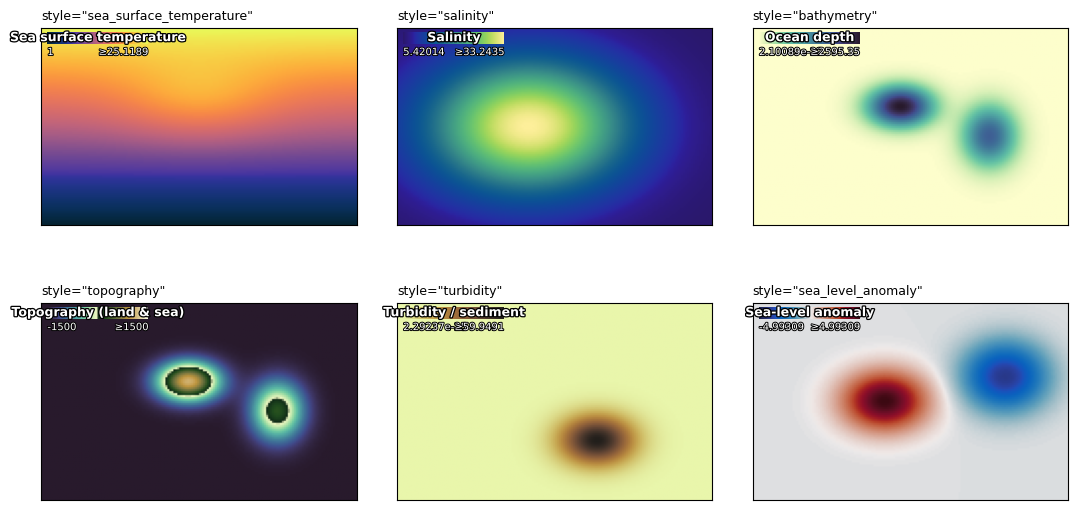

In [13]:
cmocean_demo = {
    'sea_surface_temperature': fields['temperature'],
    'salinity': fields['vegetation'] * 35,  # a 0-35 PSU-like gradient
    'bathymetry': fields['elevation'],  # depth increasing with value
    'topography': fields['elevation'] - 1500,  # now spans below/above sea level
    'turbidity': fields['precipitation'],  # a sediment-like plume
    'sea_level_anomaly': fields['anomaly'],  # +/- about zero
}
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, (style, data) in zip(axes.ravel(), cmocean_demo.items()):
    apply_data_style(ax, {style: data}, style=style)
    ax.set_title(f'style="{style}"', loc='left', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

`topography` shows the sea-level hinge working: the low half (below 0) renders in the map's ocean colours
and the high half in its land colours, split exactly at zero -- the same `center=0` mechanism the
`anomaly` preset uses, applied to elevation.

## Categorical presets -- discrete classes, not a colour ramp

Not every field is continuous. A **categorical** preset maps discrete integer class codes to fixed colours
and gets a **discrete (disjoint) legend** -- one labelled swatch per class -- instead of a gradient. The
bundled `flood_status` preset uses the near-universal NWS/USGS 5-class river-flood scale: `0` Normal (blue),
`1` Action (green), `2` Minor (yellow), `3` Moderate (orange), `4` Major (red).

In [14]:
# synthetic river-reach flood status: concentric severity zones, no-data (NaN) outside
yy, xx = np.mgrid[0:80, 0:140]
r = np.sqrt(((xx - 70) / 40) ** 2 + ((yy - 40) / 30) ** 2)
flood = np.full(xx.shape, np.nan)
for level, radius in [(0, 1.0), (1, 0.8), (2, 0.6), (3, 0.4), (4, 0.2)]:
    flood[r <= radius] = level  # inner rings overwrite with higher severity

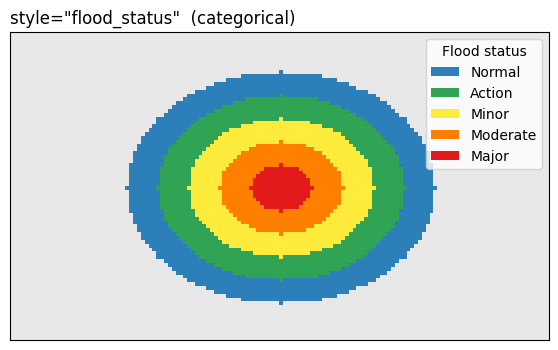

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor('#e8e8e8')  # a backdrop, to show that no-data is transparent
apply_data_style(ax, {'flood_status': flood}, style='flood_status')
ax.set_title('style="flood_status"  (categorical)', loc='left')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

Each class is a solid colour with a hard boundary (no interpolation), the legend lists the classes by name,
and the no-data cells (`NaN`) stay transparent so the grey backdrop shows through. To make your own
categorical preset -- land cover, drought category, air-quality index -- register a `DATA_STYLES` entry whose
layer carries a `categories` list of `(class_value, colour, label)` triples instead of a `cmap`.

## Hydrology rasters: flow direction & flow accumulation

Two DEM-derived rasters each need a specific treatment. **D8 flow direction** is a raster of 8 discrete
direction codes (`1`=E, `2`=SE, ... `128`=NE), so `flow_direction_d8` is a **categorical** preset coloured
cyclically -- adjacent compass directions look similar, opposites distinct. **Flow accumulation** is wildly
skewed (most cells ~0, channels enormous), so `flow_accumulation` uses a **symmetric-log** norm; its opacity
tracks the norm, so zero cells fade out and the channel network stands out (ideal over a hillshaded DEM).

In [16]:
# D8 flow direction: quantise the downhill angle to the 8 ESRI direction codes
yy2, xx2 = np.mgrid[0:80, 0:100]
angle = (np.degrees(np.arctan2(40 - yy2, 50 - xx2)) + 360) % 360
codes = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128]
)  # E, SE, S, SW, W, NW, N, NE (clockwise)
d8 = codes[(np.round(((360 - angle) % 360) / 45).astype(int)) % 8].astype(float)

# flow accumulation: a small branching channel network (skewed -- zeros plus huge values)
acc = np.zeros_like(d8)


def draw(x0, y0, x1, y1, v):
    t = np.linspace(0, 1, 200)
    px = (x0 + (x1 - x0) * t).astype(int)
    py = (y0 + (y1 - y0) * t).astype(int)
    for k in range(len(t)):
        acc[py[k], px[k]] = max(acc[py[k], px[k]], v * (1 + k / 40))


draw(50, 40, 10, 8, 2500)
draw(50, 40, 90, 12, 2000)
draw(50, 40, 30, 72, 1200)
acc.min(), acc.max()

(np.float64(0.0), np.float64(14937.5))

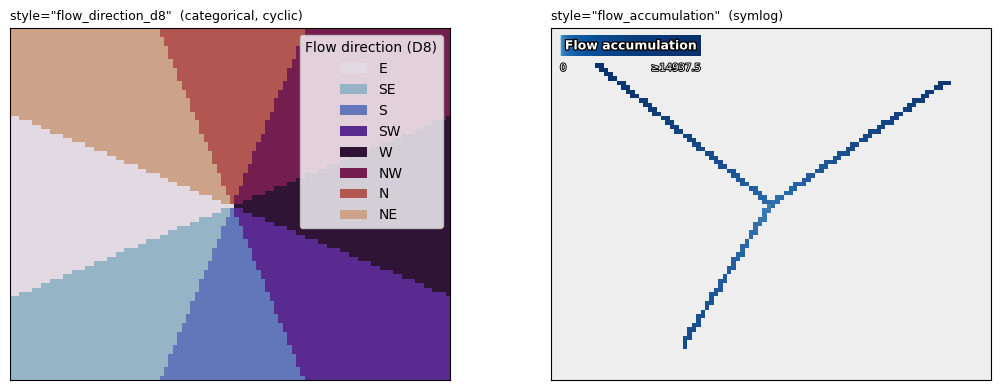

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
apply_data_style(axes[0], {'flow_direction_d8': d8}, style='flow_direction_d8')
axes[0].set_title(
    'style="flow_direction_d8"  (categorical, cyclic)', loc='left', fontsize=9
)
axes[1].set_facecolor('#eeeeee')
apply_data_style(axes[1], {'flow_accumulation': acc}, style='flow_accumulation')
axes[1].set_title('style="flow_accumulation"  (symlog)', loc='left', fontsize=9)
for a in axes:
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()

The direction raster reads as a cyclic colour wheel of compass classes; the accumulation raster shows only the
channels (zero cells are transparent, so the grey backdrop shows through) -- exactly what you want when
compositing it over a hillshaded DEM. Continuous **D-infinity** flow *angle* (0-2pi) is not discrete: use the
cyclic `phase` preset for it. Flow accumulation pairs naturally with the `hillshade` option on `ArrayGlyph`.

## Takeaway

- Apply a whole look with one call: `apply_data_style(ax, {layer: field}, style=NAME)`.
- The hand-authored climate/GIS presets are `temperature`, `elevation`, `vegetation`, `wind_speed`,
  `anomaly`, `precipitation`, and the categorical `flood_status`, plus `cams_aod`. `DATA_STYLES` also
  carries the **full weather parameter library** (keyed by a descriptive parameter name:
  `temperature_2m`, `total_precipitation`, `aerosol_optical_depth_550nm`, ...)
  and a **cmocean ocean/hydrology/DEM batch** (keyed by variable: `salinity`, `bathymetry`, ...).
- `CAMS_AOD_COLORMAPS` gives you the authentic CAMS aerosol colour scales as plain
  colormaps.
- Presets carry the policy so you do not have to: **auto-ranging** for varied real data, **diverging** maps
  centred on a value (anomalies, and the DEM sea-level hinge), an **opacity policy** that is opaque for full
  fields or transparent-where-low for overlays, and **categorical** class colours + a discrete legend.
- To style any raster with a preset's look, just pass your own array under the preset's layer
  key -- the colormap, range, and legend come for free.